In [154]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling


In [155]:
#tf.keras.utils.image_dataset_from_directory??

In [156]:
trainData = tf.keras.utils.image_dataset_from_directory(
    'trainData',
    image_size = (224,224),
    batch_size = 32)
#### Uncomment below after valData is uploaded
valData = tf.keras.utils.image_dataset_from_directory(
    'valData',
    image_size = (224,224),
    batch_size = 32)


Found 11332 files belonging to 3 classes.
Found 5702 files belonging to 3 classes.


In [157]:
trainData = trainData.map(lambda x, y: (x/255, y))
valData = valData.map(lambda x,y: (x/255, y))


In [158]:
# Rerun this to get a new batch
data_iterator = trainData.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

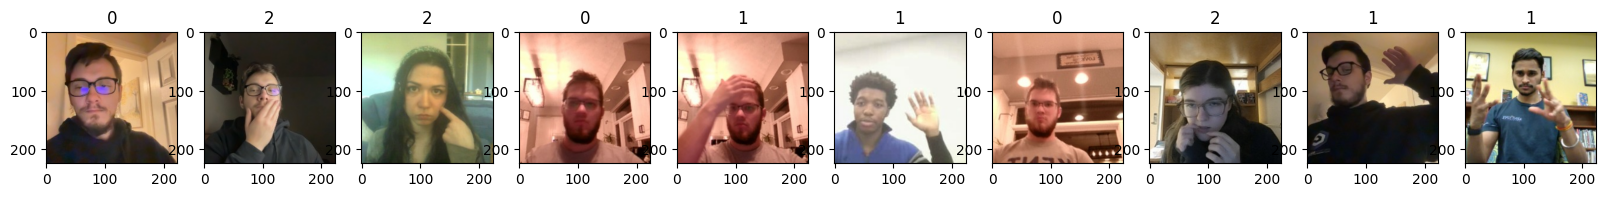

In [161]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [162]:
# Rerun this to get a new batch
val_data_iterator = valData.as_numpy_iterator()
val_batch = val_data_iterator.next()
val_batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

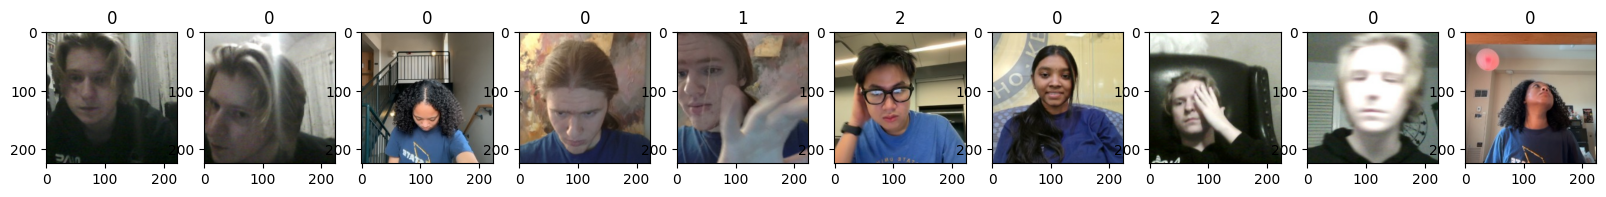

In [163]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(val_batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(val_batch[1][idx])

In [170]:
cnn = Sequential()

In [171]:
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.05))
cnn.add(RandomZoom(0.05))

# Block 1
cnn.add(Conv2D(32,(3,3),activation='relu', input_shape=(224,224,3)))
cnn.add(MaxPooling2D())

# Block 2
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

# Block 3
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

cnn.add(Dropout(0.3))   

cnn.add(Flatten())

cnn.add(Dense(64,activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(3,activation='softmax'))

c:\Users\emman\miniconda3\envs\touch_model\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Fisrt run with three Conv blocks from 32 to 164
    - very light augmentation; flip, rotate, zoom
    - dropout rate = 0.3 & 0.5 after dense
    - activation - relu and softmax
    - learning rate = 0.0001

In [172]:
cnn.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [185]:
#cnn.summary()

In [173]:
logdir = 'logs'

In [174]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [175]:
hist = cnn.fit(trainData, epochs = 10, validation_data = valData, callbacks=[tensorboard_callback])  

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 521s 1s/step - accuracy: 0.4518 - loss: 1.0249 - val_accuracy: 0.4276 - val_loss: 1.2199
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.6372 - loss: 0.7923 - val_accuracy: 0.4390 - val_loss: 1.3968
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.7362 - loss: 0.6145 - val_accuracy: 0.4230 - val_loss: 1.8582
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.7882 - loss: 0.5049 - val_accuracy: 0.4197 - val_loss: 1.6375
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 349s 984ms/step - accuracy: 0.8230 - loss: 0.4330 - val_accuracy: 0.4462 - val_loss: 2.0409
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 295s 832ms/step - accuracy: 0.8383 - loss: 0.3867 - val_accuracy: 0.4142 - val_loss: 2.0220
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.8526 - loss: 0.3544 - val_accuracy: 0.4281 - val_loss: 2.4085
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 309s 870ms/step - accuracy: 0.8686 - loss: 0.3181 -

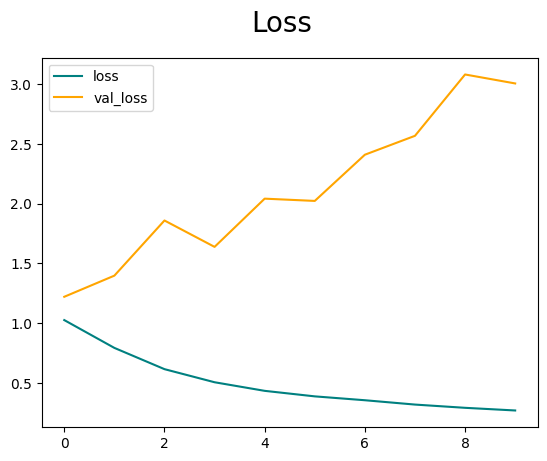

In [176]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color='orange', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc="upper left")
plt.show()

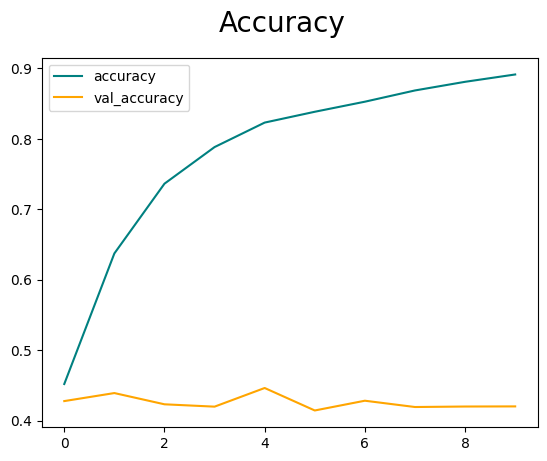

In [177]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 20)
plt.legend(loc="upper left")
plt.show()

# Saving the model

In [178]:
from tensorflow.keras.models import load_model

In [181]:
import os

In [182]:
cnn.save(os.path.join('models', 'touchmodel.h5'))

In [183]:
new_model = load_model(os.path.join('models', 'touchmodel.h5'))